# Análisis Cuantitativo de Vulnerabilidades

Este notebook consolida y analiza los reportes de vulnerabilidades generados para los repositorios de Microsoft. El flujo principal espera JSON de Grype en `data/vulnerabilities/` y, si esa carpeta no existe, usa `data/results/` como respaldo.

## Preparación del Entorno
Asegúrese de instalar las siguientes dependencias:
`pip install pandas matplotlib seaborn jupyter`

In [ ]:
import os
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Carga de Datos
Leemos todos los reportes de vulnerabilidades generados por Grype en formato JSON desde `data/vulnerabilities/`. Si esa carpeta no existe, usamos `data/results/` como respaldo.

In [ ]:
DATA_DIR_CANDIDATES = [Path("../../data/vulnerabilities"), Path("../../data/results")]
DATA_DIR = next((path for path in DATA_DIR_CANDIDATES if path.exists() and path.is_dir()), None)

all_vulnerabilities = []

if DATA_DIR is None:
    print("No se encontraron carpetas de reportes en ../../data/vulnerabilities ni ../../data/results")
else:
    for filepath in sorted(DATA_DIR.glob("*.json")):
        repo_name = filepath.stem

        try:
            with filepath.open("r", encoding="utf-8") as f:
                data = json.load(f)

            matches = data.get("matches")
            if matches is not None:
                for match in matches:
                    vuln = match.get("vulnerability", {})
                    artifact = match.get("artifact", {})
                    fix_info = vuln.get("fix", {})
                    fixed_versions = fix_info.get("versions") or []
                    all_vulnerabilities.append(
                        {
                            "repository": repo_name,
                            "vulnerability_id": vuln.get("id"),
                            "severity": vuln.get("severity"),
                            "package_name": artifact.get("name"),
                            "package_version": artifact.get("version"),
                            "package_type": artifact.get("type"),
                            "installed_version": artifact.get("version"),
                            "fixed_version": fixed_versions[0] if fixed_versions else None,
                        }
                    )
            else:
                artifacts = data.get("artifacts", [])
                for artifact in artifacts:
                    all_vulnerabilities.append(
                        {
                            "repository": repo_name,
                            "vulnerability_id": None,
                            "severity": None,
                            "package_name": artifact.get("name"),
                            "package_version": artifact.get("version"),
                            "package_type": artifact.get("type"),
                            "installed_version": artifact.get("version"),
                            "fixed_version": None,
                        }
                    )
        except Exception as e:
            print(f"Error leyendo {filepath.name}: {e}")

df = pd.DataFrame(all_vulnerabilities)
print(f"Total de registros encontrados: {len(df)}")
df.head()

Total de registros encontrados: 246


,repository,vulnerability_id,severity,package_name,package_version,package_type,installed_version,fixed_version
0,azure-sdk-for-python,GHSA-5h86-8mv2-jq9f,High,aiohttp,3.8.1,python,3.8.1,3.9.2
1,azure-sdk-for-python,GHSA-5h86-8mv2-jq9f,High,aiohttp,3.8.3,python,3.8.3,3.9.2
2,azure-sdk-for-python,GHSA-j8r2-6x86-q33q,Medium,requests,2.28.1,python,2.28.1,2.31.0
3,azure-sdk-for-python,GHSA-45c4-8wx5-qw6w,Medium,aiohttp,3.8.1,python,3.8.1,3.8.5
4,azure-sdk-for-python,GHSA-45c4-8wx5-qw6w,Medium,aiohttp,3.8.3,python,3.8.3,3.8.5


## 2. Análisis de Severidad
Distribución de las vulnerabilidades agrupadas por su nivel de severidad (Negligible, Low, Medium, High, Critical).

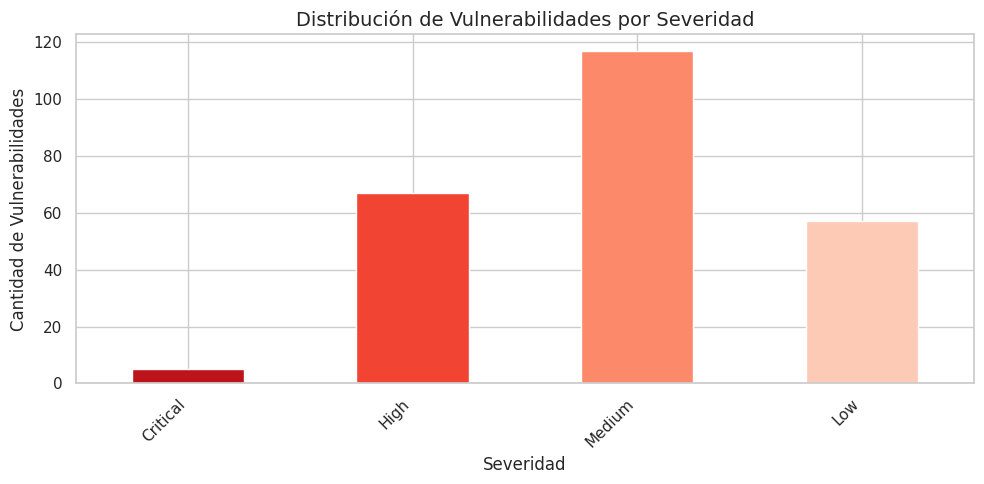

In [ ]:
# Definir el orden lógico de las severidades
severity_order = ["Critical", "High", "Medium", "Low", "Negligible", "Unknown"]

if df.empty or "severity" not in df.columns:
    print("No hay datos de severidad para graficar.")
else:
    severity_series = df["severity"].fillna("Unknown")
    severity_counts = severity_series.value_counts().reindex(severity_order).dropna()

    plt.figure(figsize=(10, 5))
    severity_counts.plot(kind="bar", color=sns.color_palette("Reds_r", len(severity_counts)))
    plt.title("Distribución de Vulnerabilidades por Severidad", fontsize=14)
    plt.xlabel("Severidad")
    plt.ylabel("Cantidad de Vulnerabilidades")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 3. Vulnerabilidades por Repositorio
Identificamos los repositorios con mayor cantidad de vulnerabilidades, para enfocar los esfuerzos de remediación.

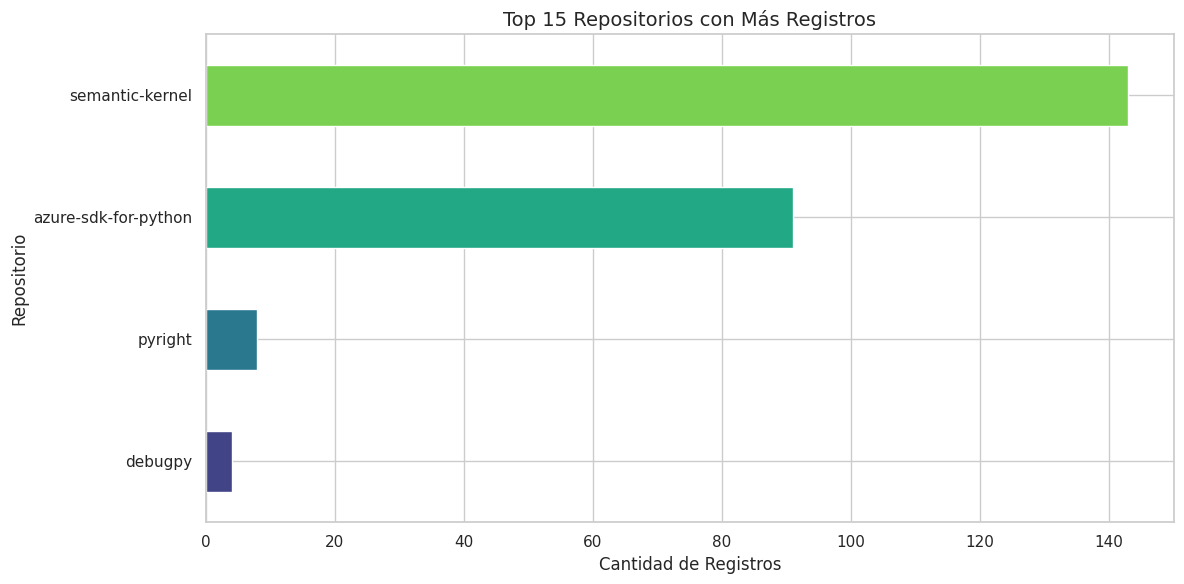

In [ ]:
if df.empty or "repository" not in df.columns:
    print("No hay datos de repositorio para graficar.")
else:
    repo_counts = df["repository"].value_counts().head(15)

    plt.figure(figsize=(12, 6))
    repo_counts.sort_values().plot(kind="barh", color=sns.color_palette("viridis", len(repo_counts)))
    plt.title("Top 15 Repositorios con Más Registros", fontsize=14)
    plt.xlabel("Cantidad de Registros")
    plt.ylabel("Repositorio")
    plt.tight_layout()
    plt.show()

## 4. Paquetes Más Afectados
Análisis de las librerías o dependencias que introducen la mayor cantidad de riesgos (Top 10).

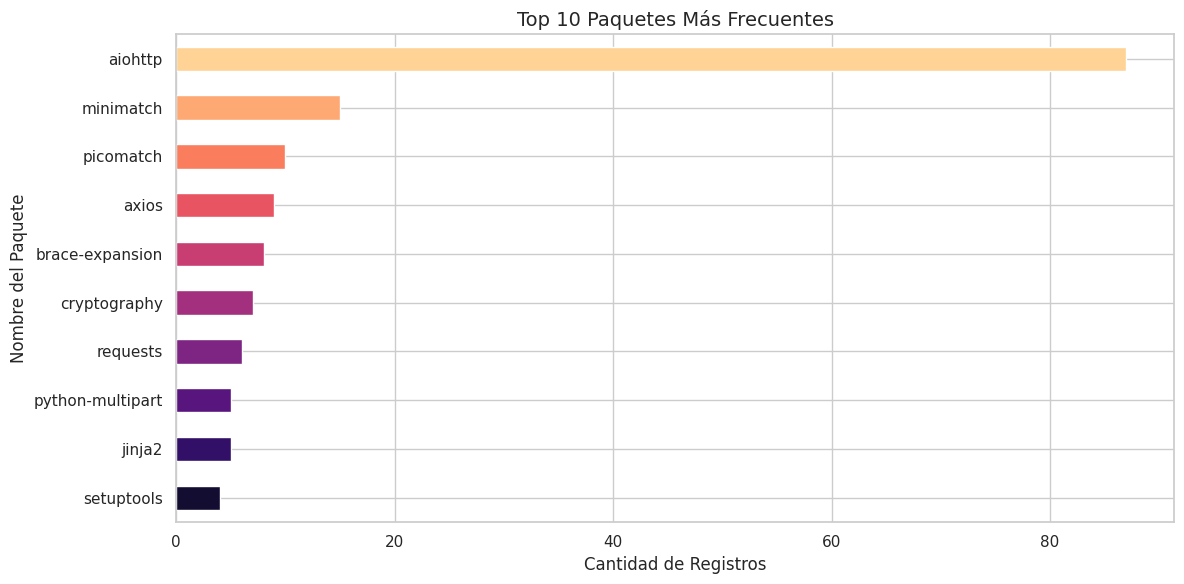

In [ ]:
if df.empty or "package_name" not in df.columns:
    print("No hay datos de paquetes para graficar.")
else:
    pkg_counts = df["package_name"].fillna("Unknown").value_counts().head(10)

    plt.figure(figsize=(12, 6))
    pkg_counts.sort_values().plot(kind="barh", color=sns.color_palette("magma", len(pkg_counts)))
    plt.title("Top 10 Paquetes Más Frecuentes", fontsize=14)
    plt.xlabel("Cantidad de Registros")
    plt.ylabel("Nombre del Paquete")
    plt.tight_layout()
    plt.show()

## 5. Resumen de Vulnerabilidades Críticas y Altas
Detalle de las vulnerabilidades más críticas para planificar acciones inmediatas.

In [ ]:
if df.empty or "severity" not in df.columns:
    print("No hay datos de severidad para resumir.")
else:
    critical_high_df = df[df["severity"].isin(["Critical", "High"])].copy()
    summary = (
        critical_high_df.groupby(["repository", "package_name", "severity"])
        .size()
        .reset_index(name="count")
    )
    display(summary.sort_values(by=["severity", "count"], ascending=[True, False]).head(15))

,repository,package_name,severity,count
20,semantic-kernel,processwithcloudevents-client,Critical,2
27,semantic-kernel,semantic-kernel,Critical,2
2,azure-sdk-for-python,cspell-version-pin,Critical,1
18,semantic-kernel,minimatch,High,12
0,azure-sdk-for-python,aiohttp,High,6
5,azure-sdk-for-python,setuptools,High,4
15,semantic-kernel,flatted,High,4
19,semantic-kernel,picomatch,High,4
9,pyright,minimatch,High,3
12,semantic-kernel,axios,High,3


## Conclusiones
- Los repositorios con más registros concentran más superficie de revisión.
- Las vulnerabilidades de tipo 'Critical' y 'High' se concentran en unas pocas dependencias.
- Este análisis sirve como base para priorizar remediaciones sobre los repositorios de Microsoft.